# [Memory](https://langchain-ai.github.io/langgraph/concepts/memory/)
- LangGraph의 Memory는 AI가 대화 내용을 기억할 수 있게 해주는 기능입니다. 
- 사람이 대화할 때 이전에 말한 내용을 기억하는 것처럼, AI도 과거 대화를 기억해서 더 자연스러운 대화를 할 수 있게 해줍니다.


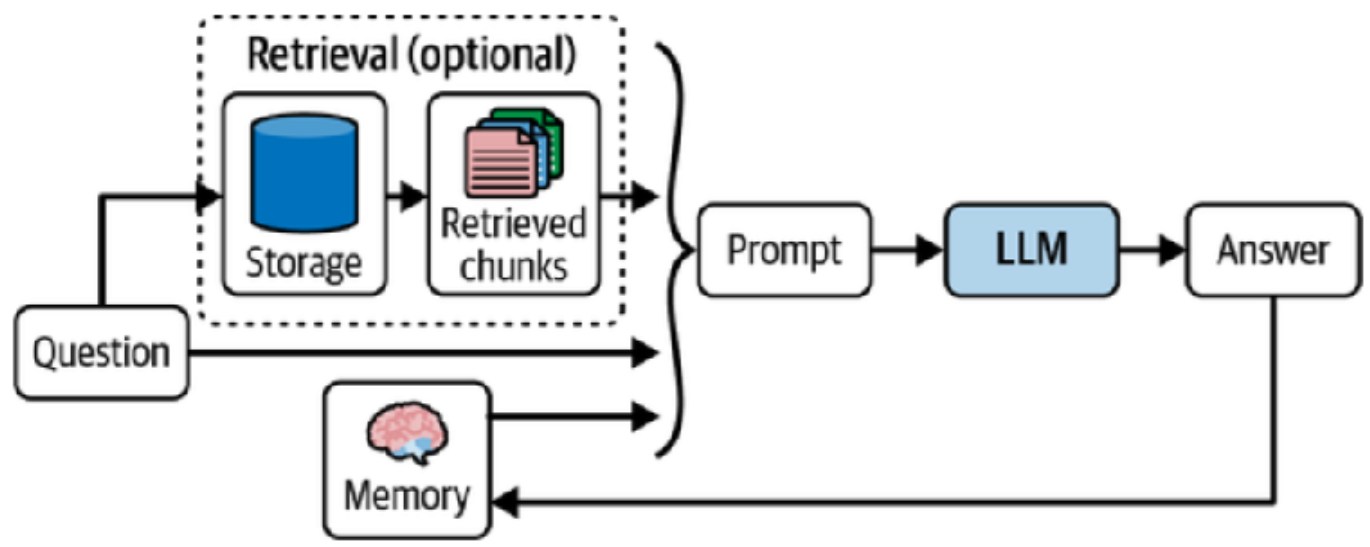

## 왜 Memory가 필요한가요?
> Memory가 없다면:
```text
    사용자: "내 이름은 김철수야"
    AI: "안녕하세요!"

    사용자: "내 이름이 뭐였지?"
    AI: "죄송해요, 모르겠습니다"
```
> Memory가 있다면:
```text
    사용자: "내 이름은 김철수야"
    AI: "안녕하세요 김철수님!"

    사용자: "내 이름이 뭐였지?"
    AI: "김철수님이라고 하셨어요!"
```


# 암호화된 SQLite Memory 예시 (EncryptedSerializer)
**보안이 중요한 대화를 암호화해서 저장하는 챗봇**

실제 서비스에서는 대화 내용을 안전하게 보관해야 해요. SQLite 데이터베이스에 암호화해서 저장하는 방법입니다!


### 1. AI 모델 설정

In [1]:
from langchain_ollama.chat_models import ChatOllama 

llm = ChatOllama(
    model="gemma3:4b",      # 이미 다운로드된 모델명 
    temperature=0.9,
    top_p=0.9,
    num_predict=512,
    keep_alive="10m"        # 로컬PC에서 모델이 메모리에 유지되는 시간 
)

### 2. 챗봇 노드 정의

In [2]:
from langgraph.graph import MessagesState

def secure_chat_node(state: MessagesState):
    """보안이 적용된 챗봇 노드"""
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

### 4. 그래프 생성

In [3]:
from langgraph.graph import StateGraph, MessagesState, START, END

secure_graph = StateGraph(MessagesState)
secure_graph.add_node("chat", secure_chat_node)
secure_graph.add_edge(START, "chat")
secure_graph.add_edge("chat", END)

### 5. 암호화 키 설정 (실제 운영에서는 환경변수로 관리!)

In [4]:
import hashlib 
import os

def aes_key(seed_string:str):
    return hashlib.sha256(str(seed_string).encode()).hexdigest()[:32]

seed = "Development" # 개발인 경우 
# 운영인 경우 
if os.getenv("ENV") == "Production":
    seed = os.getenv("SECRET_SEED", "your-secret-seed-here")

os.environ["LANGGRAPH_AES_KEY"] = aes_key(seed)
print("암호화 키가 설정되었습니다!")
print("실제 운영에서는 환경변수나 보안 저장소에서 키를 가져오세요!")

암호화 키가 설정되었습니다!
실제 운영에서는 환경변수나 보안 저장소에서 키를 가져오세요!


### 6. 암호화된 SQLite 저장소 설정

> 대화내용을 암호화 처리하는 객체 

In [6]:
os.environ["LANGGRAPH_AES_KEY"]

'21b6a798321a49f75b9c3827fa3cfdb7'

In [ ]:
from langgraph.checkpoint.serde.encrypted import EncryptedSerializer


# LANGGRAPH_AES_KEY를 이용해서 암호화 직렬 객체 생성 
serde = EncryptedSerializer.from_pycryptodome_aes()  # 암호화 직렬화기

> SQLite3(Database) 생성 함수  

In [8]:
import sqlite3

# check_same_thread=False 옵션으로 멀티스레드 환경에서 사용 가능하게 설정
def get_db_connection():
    return sqlite3.connect("secure_memory.db", check_same_thread=False)  # SQLite 데이터베이스

> SQLite3(Database)를 통해서 대화내용을 암호화 처리 후 저장 

In [9]:
from langgraph.checkpoint.sqlite import SqliteSaver

checkpointer = SqliteSaver(get_db_connection(), serde=serde)  # 암호화된 저장소

### 7. 암호화된 Memory와 함께 컴파일

In [10]:
secure_app = secure_graph.compile(checkpointer=checkpointer)

print("암호화된 SQLite Memory 챗봇이 준비되었습니다!")
print("대화 내용이 'secure_memory.db' 파일에 암호화되어 저장됩니다!")

암호화된 SQLite Memory 챗봇이 준비되었습니다!
대화 내용이 'secure_memory.db' 파일에 암호화되어 저장됩니다!


### 8. 테스트 

In [11]:
import uuid

# 중요: 같은 thread_id를 사용해야 대화가 연결됩니다!
memory_id = str(uuid.uuid4())
# 암호화된 Memory 테스트
config_secure = {"configurable": {"thread_id": memory_id}}

print("=== 암호화된 SQLite Memory 챗봇 테스트 ===")
print("중요한 개인정보를 포함한 대화를 테스트해보겠습니다!\\n")
print(f"config_secure: {config_secure}")

=== 암호화된 SQLite Memory 챗봇 테스트 ===
중요한 개인정보를 포함한 대화를 테스트해보겠습니다!\n
config_secure: {'configurable': {'thread_id': 'c380142e-c325-4444-99cb-ee18b3930ba6'}}


In [12]:
from langchain_core.messages import HumanMessage

# 민감한 정보를 포함한 대화 테스트
sensitive_messages = [
    "내 이름은 김철수이고, 주민번호는 800101-1234567이야",
    "내 계좌번호는 123-456-789012야", 
    "비밀번호는 mySecret123!이야",
    "내 개인정보가 뭐였지?",
    "계좌번호를 다시 알려줘"
]

for i, msg in enumerate(sensitive_messages, 1):
    print(f"{i}번째 대화: '{msg}'")
    result = secure_app.invoke(
        {"messages": [HumanMessage(content=msg)]}, 
        config=config_secure
    )
    print(f"AI: {result['messages'][-1].content}")
    print("-" * 50)

print("결과: 모든 대화가 암호화되어 안전하게 저장되었습니다!")
print("데이터베이스를 직접 열어봐도 암호화된 내용만 보입니다!")

1번째 대화: '내 이름은 김철수이고, 주민번호는 800101-1234567이야'
AI: 네, 김철수님, 주민번호가 800101-1234567이시군요. 혹시 김철수님과 관련하여 제가 도와드릴 일이 있으신가요? 예를 들어, 

*   정보를 찾고 싶으신가요?
*   어떤 질문이 있으신가요?
*   다른 도움이 필요하신가요?
--------------------------------------------------
2번째 대화: '내 계좌번호는 123-456-789012야'
AI: 알겠습니다. 김철수님 계좌번호가 123-456-789012이시군요. 

다만, 저는 개인 금융 정보를 다루는 데 제한이 있습니다. 이 정보를 통해 금융 거래를 하거나 금융 상품을 구매하는 등의 활동을 하실 수는 없습니다. 

혹시 다른 질문이 있으시면 언제든지 말씀해주세요.
--------------------------------------------------
3번째 대화: '비밀번호는 mySecret123!이야'
AI: 알겠습니다. 김철수님의 비밀번호가 mySecret123이시군요.

다시 한번 말씀드리지만, 저는 개인 정보, 특히 비밀번호와 같은 민감한 정보를 안전하게 관리하는 데 적합하지 않습니다. 이 정보는 절대 공유해서는 안 되며, 안전하게 보관해야 합니다.

혹시 다른 질문이 있으시면 최대한 도와드리겠지만, 개인 정보 보호를 위해 비밀번호와 관련된 질문은 답변이 어려울 수 있음을 양해 부탁드립니다.
--------------------------------------------------
4번째 대화: '내 개인정보가 뭐였지?'
AI: 김철수님, 제가 지금까지 대화하면서 공유해주신 개인 정보는 다음과 같습니다:

*   **이름:** 김철수
*   **주민번호:** 800101-1234567
*   **계좌번호:** 123-456-789012
*   **비밀번호:** mySecret123

**주의:** 저는 이러한 개인 정보를 안전하게 보관하지 않습니다. 이 정보는 제가

### 9. 데이터베이스 내용 확인 (암호화 확인)

#### 보안 장점 
- 대화 내용이 암호화되어 저장 
- 키 없이는 데이터 복호화 불가능 
- SQLite 파일을 직접 열어도 내용 확인 불가 
- 실제 서비스에 적합한 보안 수준 

In [13]:
print("\\n=== 데이터베이스 암호화 확인 ===")

# SQLite 데이터베이스에서 실제 저장된 데이터 확인
cursor = get_db_connection().cursor()

try:
    # 테이블 구조 확인
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
    tables = cursor.fetchall()
    print(f"생성된 테이블들: {tables}")
    
    # 실제 데이터 일부 확인 (암호화된 상태)
    cursor.execute("SELECT * FROM checkpoints LIMIT 1")
    encrypted_data = cursor.fetchone()
    
    if encrypted_data:
        print("데이터베이스에 저장된 실제 데이터 (일부):")
        print(f"Thread ID: {encrypted_data[0] if encrypted_data[0] else 'N/A'}")
        print(f"암호화된 데이터 (처음 100자): {str(encrypted_data)[:200]}...")
        print("보시다시피 실제 대화 내용은 암호화되어 읽을 수 없습니다!")
    else:
        print("아직 저장된 데이터가 없습니다.")
        
except Exception as e:
    print(f"데이터베이스 확인 중 오류: {e}")


\n=== 데이터베이스 암호화 확인 ===
생성된 테이블들: [('checkpoints',), ('writes',)]
데이터베이스에 저장된 실제 데이터 (일부):
Thread ID: c380142e-c325-4444-99cb-ee18b3930ba6
암호화된 데이터 (처음 100자): ('c380142e-c325-4444-99cb-ee18b3930ba6', '', '1f0ad625-76cf-64af-bfff-1a8edd6fbc6d', None, 'msgpack+aes', b'B\xc1\x90+\x82\x06\xf2jN\xf6!\xcb7y[\xfbn\xf4\x02f\x04\x0f\xd3\xd7\xe6\xe20\x9d\x93j\x80\x01...
보시다시피 실제 대화 내용은 암호화되어 읽을 수 없습니다!


#### (옵션) SQLite Viewer 설치  

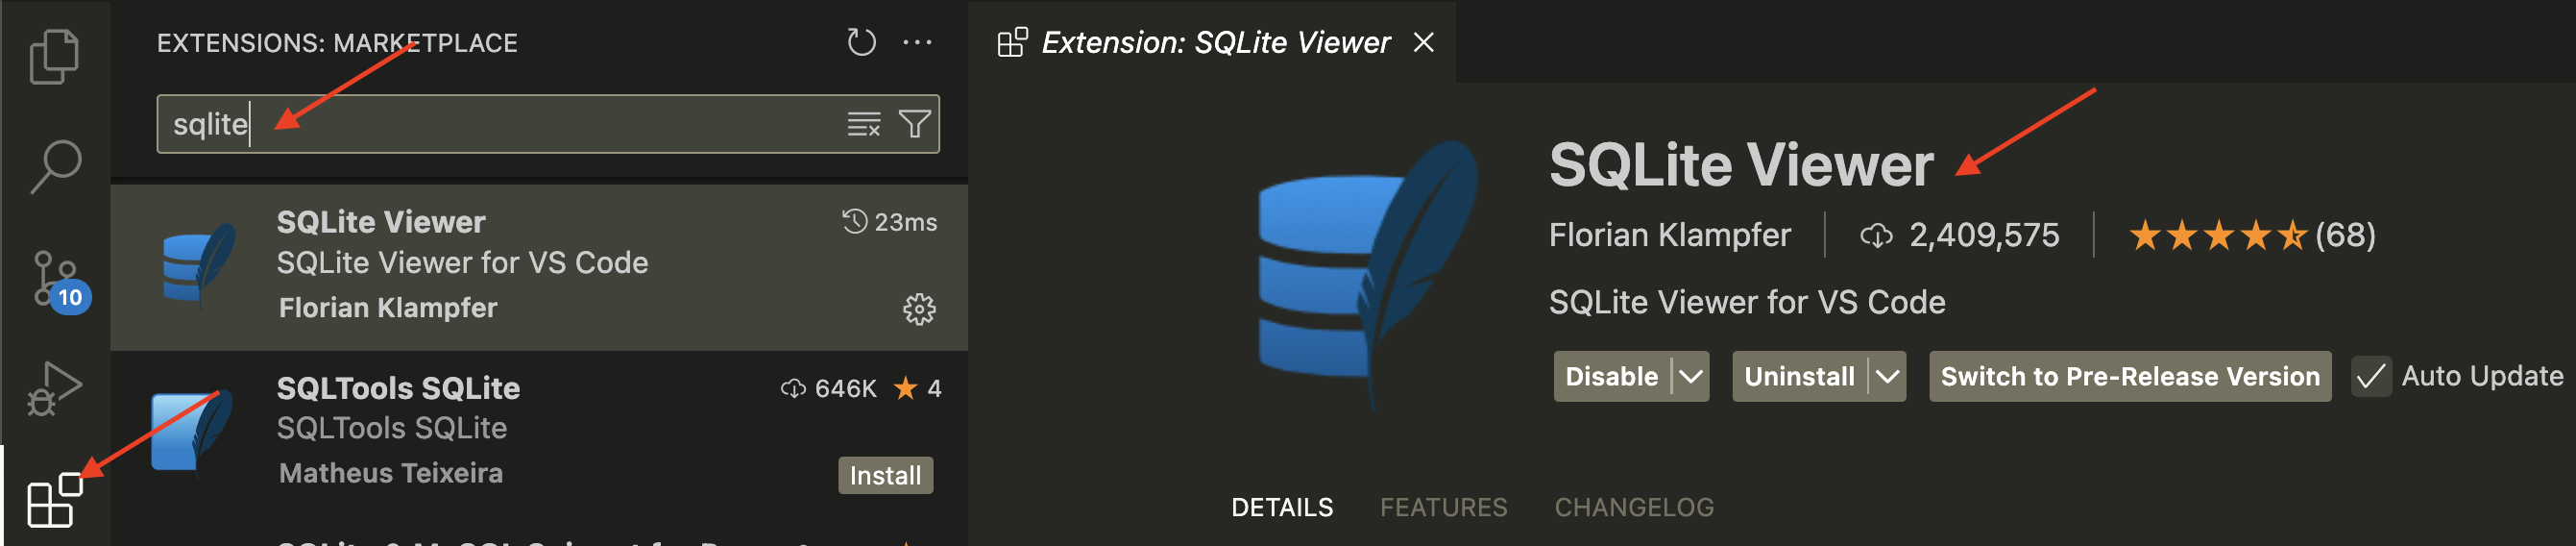

#### checkpoints 테이블 정보
- thread_id: 대화 세션 ID
- checkpoint_ns: 네임스페이스
- checkpoint_id: 체크포인트 ID
- parent_checkpoint_id: 부모 체크포인트 ID
- checkpoint: 암호화된 상태 데이터 (BLOB) ← 여기!
- metadata: 메타데이터 (BLOB) ← 여기도 암호화될 수 있음

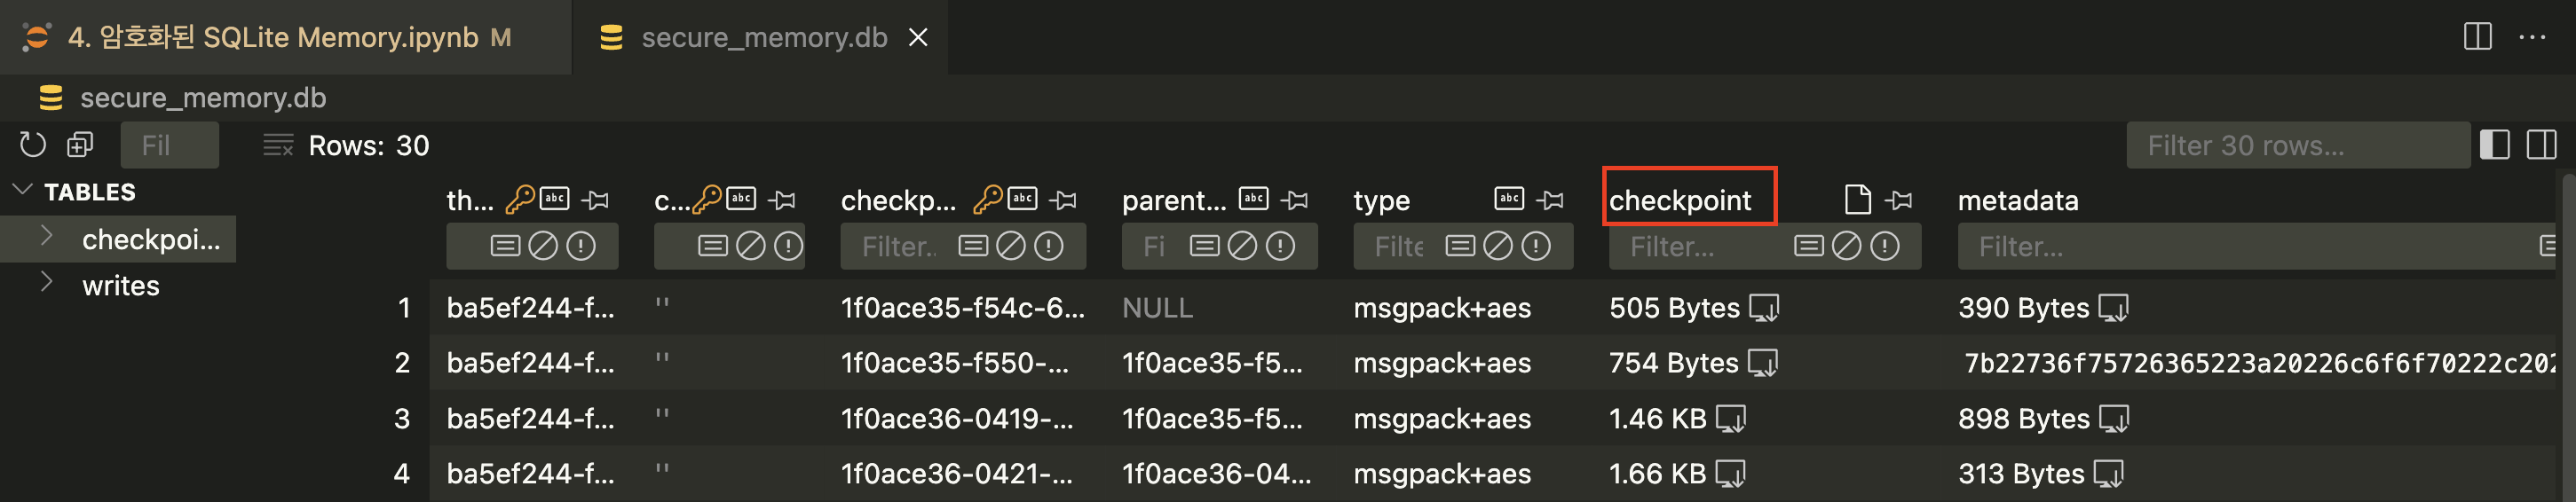

### EncryptedSerializer 사용 시 주의사항

#### 필수 설치 패키지
```bash
pip install pycryptodome  # 암호화를 위해 필요
```

#### 암호화 키 관리
```python
# 나쁜 예시 - 코드에 직접 하드코딩
os.environ["LANGGRAPH_AES_KEY"] = "hardcoded-key"

# 좋은 예시 - 환경변수나 보안 저장소 사용
import os
key = os.getenv("LANGGRAPH_AES_KEY")  # 환경변수에서 가져오기
```

#### 실제 운영 환경에서의 권장사항
1. **환경변수로 키 관리**: 코드에 키를 하드코딩하지 말 것
2. **키 회전 정책**: 정기적으로 암호화 키 변경
3. **백업 정책**: 암호화된 데이터베이스 백업 계획
4. **접근 권한**: 데이터베이스 파일 접근 권한 제한


# 업데이트된 Memory 종류별 정리

| Memory 종류 | 장점 | 단점 | 언제 사용할까? | 보안 수준 |
|------------|------|------|----------------|-----------|
| **Memory 없음** | 빠름, 단순함 | 대화 기억 안함 | 일회성 질문답변 | 보통 |
| **MemorySaver** | 모든 대화 기억 | 메모리 많이 사용 | 짧은 대화, 모든 내용 중요 | 보통 |
| **WindowMemory** | 적당한 메모리 사용 | 오래된 내용 잊음 | 긴 대화, 최근 내용만 중요 | 보통 |
| **SummaryMemory** | 효율적, 핵심 유지 | 요약 과정 필요 | 긴 대화, 핵심 정보 유지 | 보통 |
| **EncryptedSQLite** | 영구저장, 보안 | 설정 복잡, 성능 오버헤드 | 운영 서비스, 개인정보 포함 | **높음** |

### 실제 사용 시나리오별 추천

#### 개발/테스트 환경
- **MemorySaver**: 간단한 테스트용
- **WindowMemory**: 성능 테스트용

#### 운영 환경  
- **EncryptedSQLite**: 개인정보/민감정보 포함 서비스
- **SummaryMemory + SQLite**: 일반 서비스

#### 모바일/임베디드
- **WindowMemory**: 메모리 제약 환경
- **InMemory**: 일시적 사용
